# Project 5B: Flow Matching from Scratch!

## Setup environment

In [1]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

In [2]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [3]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x
        # ===== end of code ====
        #raise NotImplementedError()


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x
        # ===== end of code ====
        #raise NotImplementedError()


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x
        # ===== end of code ====
        #raise NotImplementedError()


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        # ===== your code here! ====
        self.pool = nn.AvgPool2d(kernel_size=7) #flatten by 7x7
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.pool(x)
        # ===== end of code ====
        #raise NotImplementedError()


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=7)
        self.bn = nn.BatchNorm2d(in_channels)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x
        # ===== end of code ====
        #raise NotImplementedError()


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv1 = Conv(in_channels, out_channels)
        self.conv2 = Conv(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv1(x)
        x = self.conv2(x)
        return x
        # ===== end of code ====
        #raise NotImplementedError()


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = Conv(in_channels, out_channels)
        self.down = DownConv(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv(x)
        x = self.down(x)
        return x
        # ===== end of code ====
        #raise NotImplementedError()


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.up = UpConv(in_channels, out_channels)
        self.conv = Conv(out_channels, out_channels)

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.up(x)
        x = self.conv(x)
        return x
        # ===== end of code ====
        #raise NotImplementedError()

## Implementing Unconditional UNet

In [4]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens

        self.conv_in = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2*D)

        self.flatten = Flatten()
        self.unflatten = Unflatten(2*D)

        self.up1 = UpBlock(2*D, D)
        self.up2 = UpBlock(2*D, D) #skippped connections
        self.conv_out = nn.Conv2d(2*D, in_channels, kernel_size=1)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        x1 = self.conv_in(x)  # (B, D, 28, 28)
        x2 = self.down1(x1)   # (B, D, 14, 14)
        x3 = self.down2(x2)   # (B, 2D, 7, 7)

        x4 = self.flatten(x3)   # (B, 2D, 1, 1)
        x5 = self.unflatten(x4) # (B, 2D, 7, 7)

        x6 = self.up1(x5)                      # (B, D, 14, 14)
        x7 = torch.cat([x6, x2], dim=1)        # (B, 2D, 14, 14) - concatenate with skip
        x8 = self.up2(x7)                      # (B, D, 28, 28)
        x9 = torch.cat([x8, x1], dim=1)        # (B, 2D, 28, 28) - concatenate with skip
        out = self.conv_out(x9)                # (B, in_channels, 28, 28)

        return out
        # ===== end of code ====
        #raise NotImplementedError()

# Part 1.2: Using the UNet to Train a Denoiser

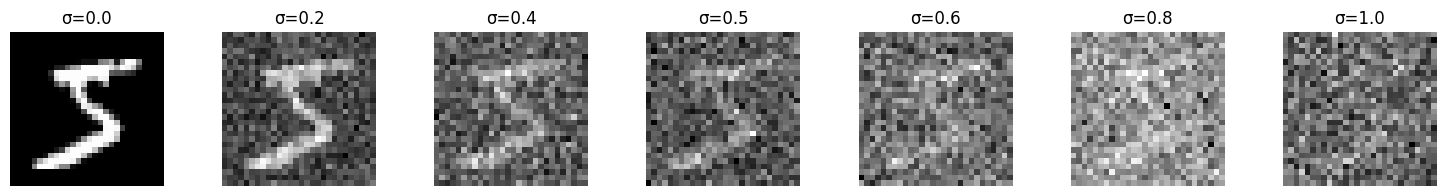

In [5]:
# Visualize images at different noisy level
# ===== your code here! ====
# Load MNIST
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())

# Get a sample image
sample_image = train_dataset[0][0]  # Shape: (1, 28, 28)

# Noise levels
sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

# Visualize
fig, axes = plt.subplots(1, len(sigmas), figsize=(15, 2))
for i, sigma in enumerate(sigmas):
    noise = torch.randn_like(sample_image) * sigma
    noisy_image = sample_image + noise
    axes[i].imshow(noisy_image.squeeze(), cmap='gray')
    axes[i].set_title(f'σ={sigma}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()
# ===== end of code ====

## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [6]:
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 256
learning_rate = 1e-4
noise_level = 0.5
hidden_dim = 128
num_epochs = 5
# ===== end of code ====

In [7]:
# Define your datasets and dataloaders
# ===== your code here! ====
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# ===== end of code ====

In [8]:
# Define your model, optimizer, and loss
# ===== your code here! ====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UnconditionalUNet(in_channels=1, num_hiddens=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
# ===== end of code ====

100%|██████████| 235/235 [01:08<00:00,  3.43it/s]


Epoch 1/5, Avg Loss: 0.0205


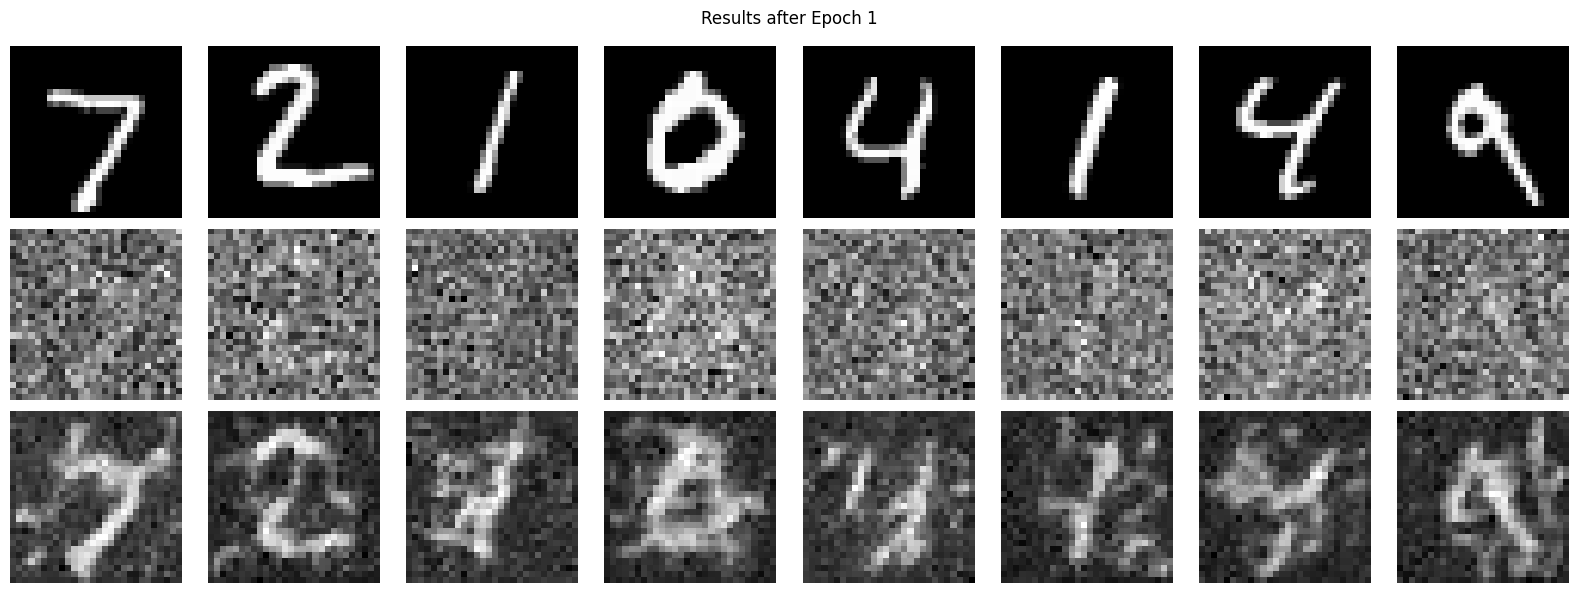

100%|██████████| 235/235 [01:07<00:00,  3.47it/s]


Epoch 2/5, Avg Loss: 0.0118


100%|██████████| 235/235 [01:07<00:00,  3.49it/s]


Epoch 3/5, Avg Loss: 0.0105


100%|██████████| 235/235 [01:07<00:00,  3.49it/s]


Epoch 4/5, Avg Loss: 0.0097


100%|██████████| 235/235 [01:07<00:00,  3.48it/s]


Epoch 5/5, Avg Loss: 0.0093


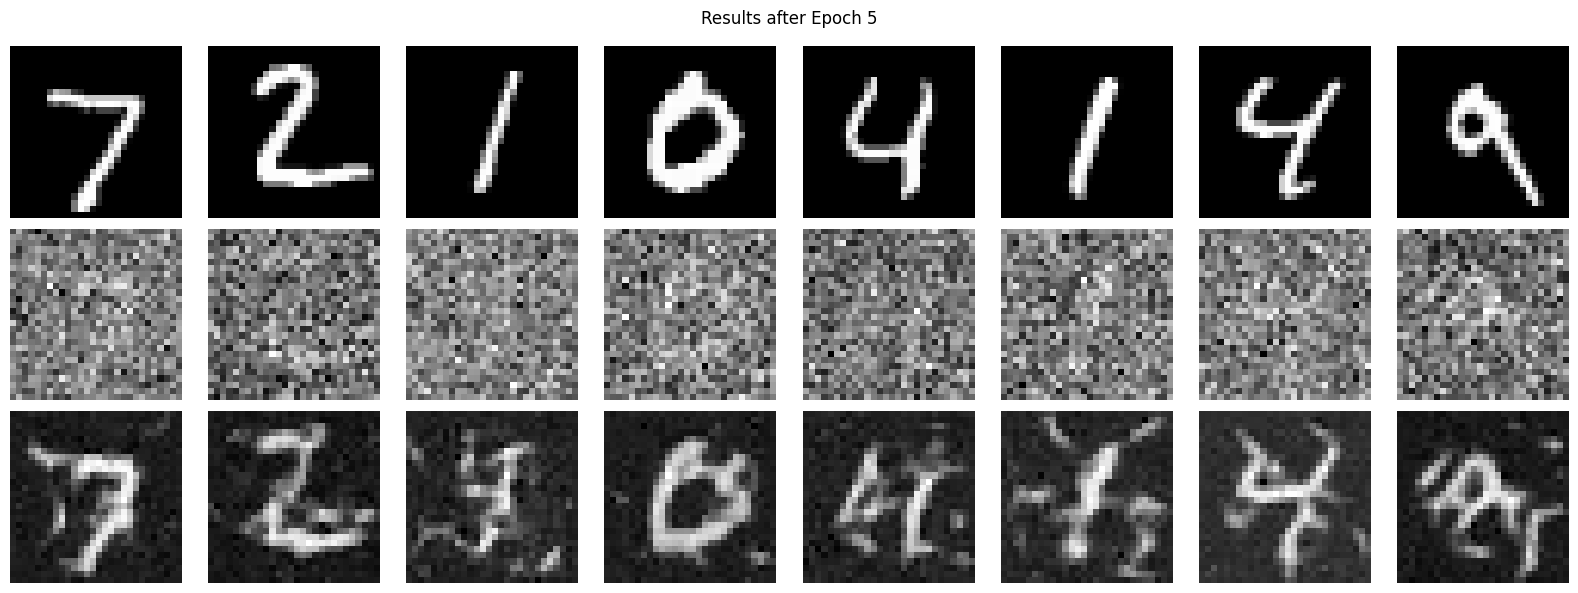

In [9]:
# The training loops
train_losses = []
for epoch in range(num_epochs):
    model.train()
    for i, (images, _) in enumerate(tqdm(train_loader)):

        # ===== your code here! ====
        images = images.to(device)

        # Add noise to images: z = x + σ * ε
        noise = torch.randn_like(images) * noise_level
        noisy_images = images + noise

        # Denoise: predict clean image from noisy image
        outputs = model(noisy_images)

        # ===== end of code ====

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
    print(f'Epoch {epoch+1}/{num_epochs}, Avg Loss: {sum(train_losses[-len(train_loader):])/len(train_loader):.4f}')
    if epoch == 0 or epoch == num_epochs - 1:
        model.eval()
        with torch.no_grad():
            test_images, _ = next(iter(test_loader))
            test_images = test_images[:8].to(device)

            # Add noise
            test_noise = torch.randn_like(test_images) * sigma
            test_noisy = test_images + test_noise
            test_denoised = model(test_noisy)

            # Plot
            fig, axes = plt.subplots(3, 8, figsize=(16, 6))
            for i in range(8):
                axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
                axes[0, i].axis('off')
                axes[1, i].imshow(test_noisy[i].cpu().squeeze(), cmap='gray')
                axes[1, i].axis('off')
                axes[2, i].imshow(test_denoised[i].cpu().squeeze(), cmap='gray')
                axes[2, i].axis('off')
            axes[0, 0].set_ylabel('Original', rotation=0, size='large', labelpad=40)
            axes[1, 0].set_ylabel('Noisy', rotation=0, size='large', labelpad=40)
            axes[2, 0].set_ylabel('Denoised', rotation=0, size='large', labelpad=40)
            plt.suptitle(f'Results after Epoch {epoch+1}')
            plt.tight_layout()
            plt.show()



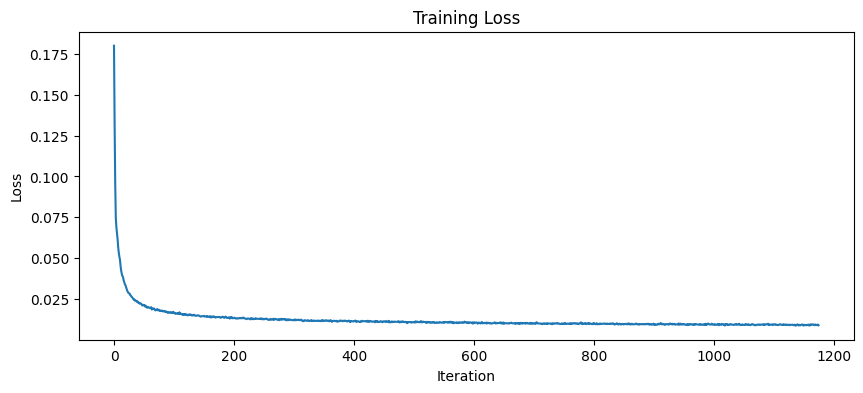

In [12]:
# Visualize your training curve
# ===== your code here! ====
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()
# ===== end of code ====

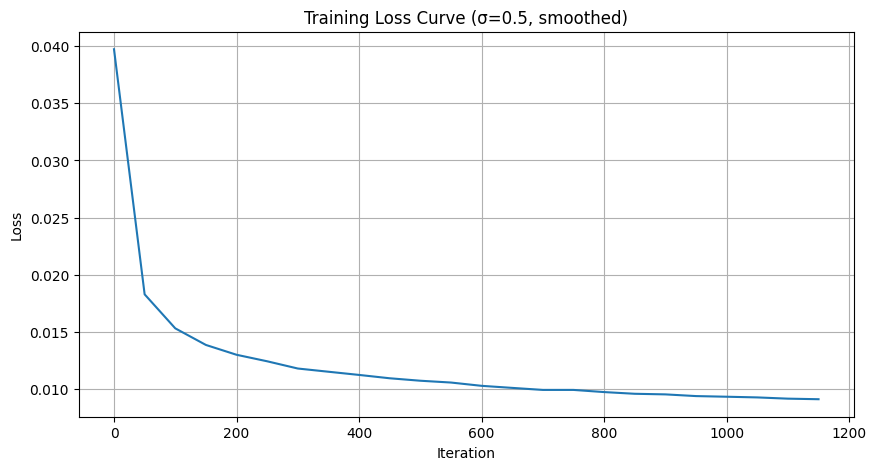

In [13]:
N = 50  # Average every 50 iterations
smoothed_losses = [sum(train_losses[i:i+N])/len(train_losses[i:i+N])
                   for i in range(0, len(train_losses), N)]

plt.figure(figsize=(10, 5))
plt.plot(range(0, len(train_losses), N), smoothed_losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve (σ=0.5, smoothed)')
plt.grid(True)
plt.show()


## Part 1.2.2: Out-of-Distribution Testing

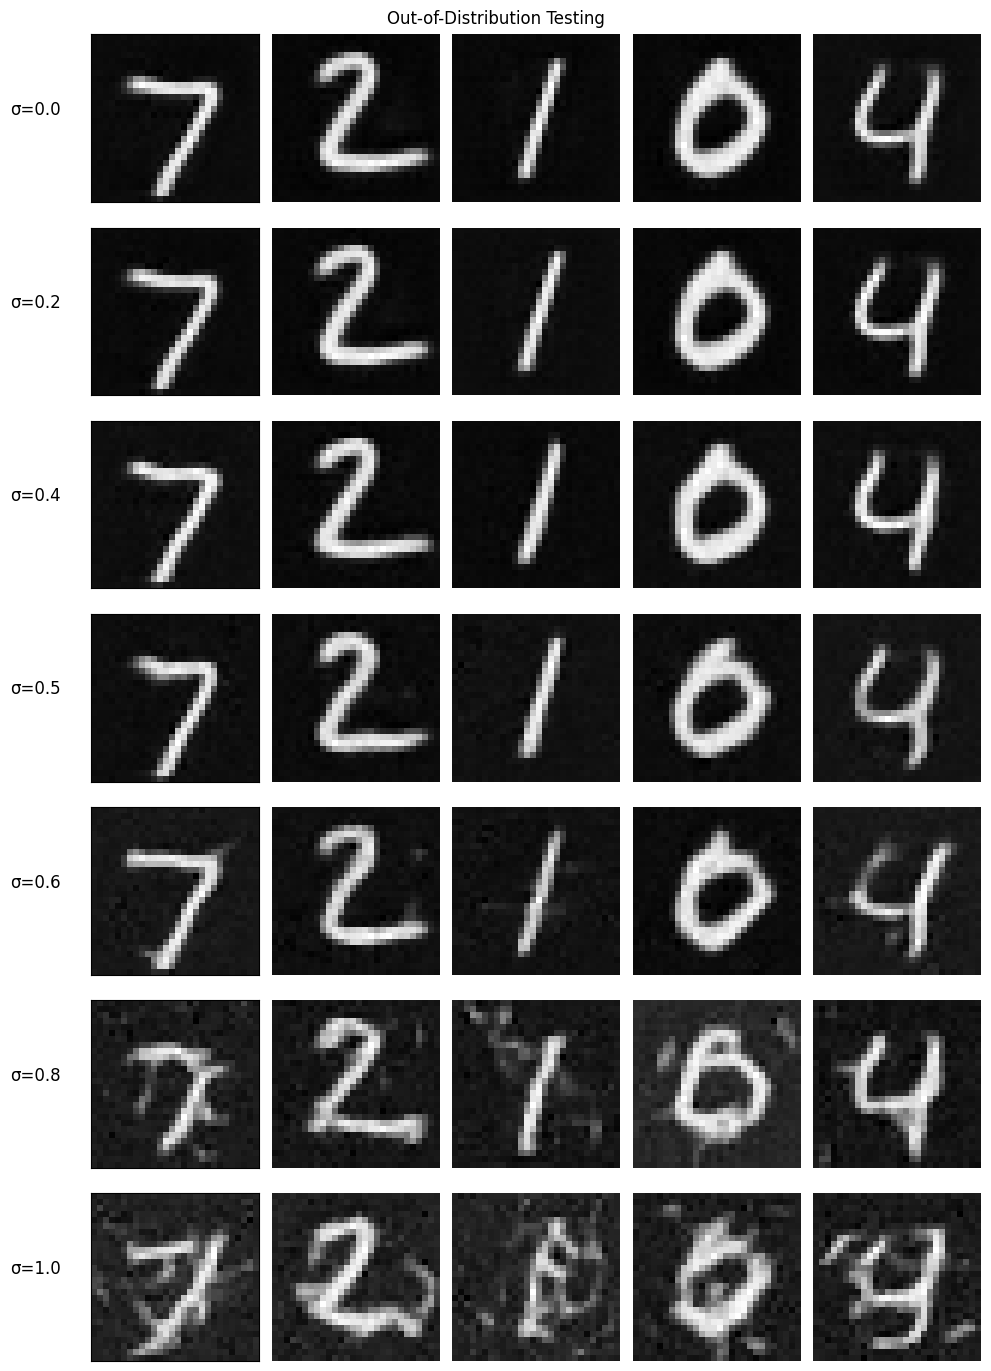

In [16]:
# Visualize OOD testing
# ===== your code here! ====
model.eval()
sigmas_test = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images[:5].to(device)

    fig, axes = plt.subplots(len(sigmas_test), 5, figsize=(10, 2*len(sigmas_test)))

    for i, sigma_test in enumerate(sigmas_test):
        # Add noise
        test_noise = torch.randn_like(test_images) * sigma_test
        test_noisy = test_images + test_noise
        test_denoised = model(test_noisy)

        for j in range(5):
            axes[i, j].imshow(test_denoised[j].cpu().squeeze(), cmap='gray')

            # hide ticks for all
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

            # but only fully hide axis for non-first columns
            if j != 0:
                axes[i, j].axis('off')

        # row caption on the left
        axes[i, 0].set_ylabel(f'σ={sigma_test}', rotation=0, size='large', labelpad=40)

    plt.suptitle('Out-of-Distribution Testing')
    plt.tight_layout()
    plt.show()


# ===== end of code ====

## Part 1.2.3 Denoising Pure Noise

100%|██████████| 235/235 [01:08<00:00,  3.42it/s]


Epoch 1/5, Avg Loss: 0.0741


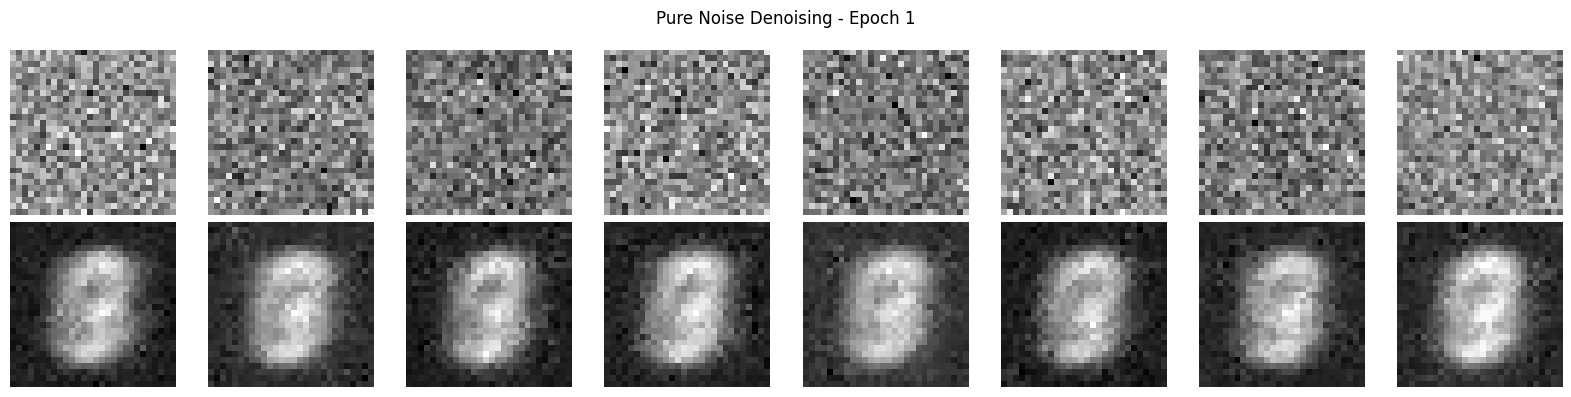

100%|██████████| 235/235 [01:07<00:00,  3.47it/s]


Epoch 2/5, Avg Loss: 0.0682


100%|██████████| 235/235 [01:07<00:00,  3.49it/s]


Epoch 3/5, Avg Loss: 0.0678


100%|██████████| 235/235 [01:07<00:00,  3.49it/s]


Epoch 4/5, Avg Loss: 0.0676


100%|██████████| 235/235 [01:07<00:00,  3.49it/s]


Epoch 5/5, Avg Loss: 0.0675


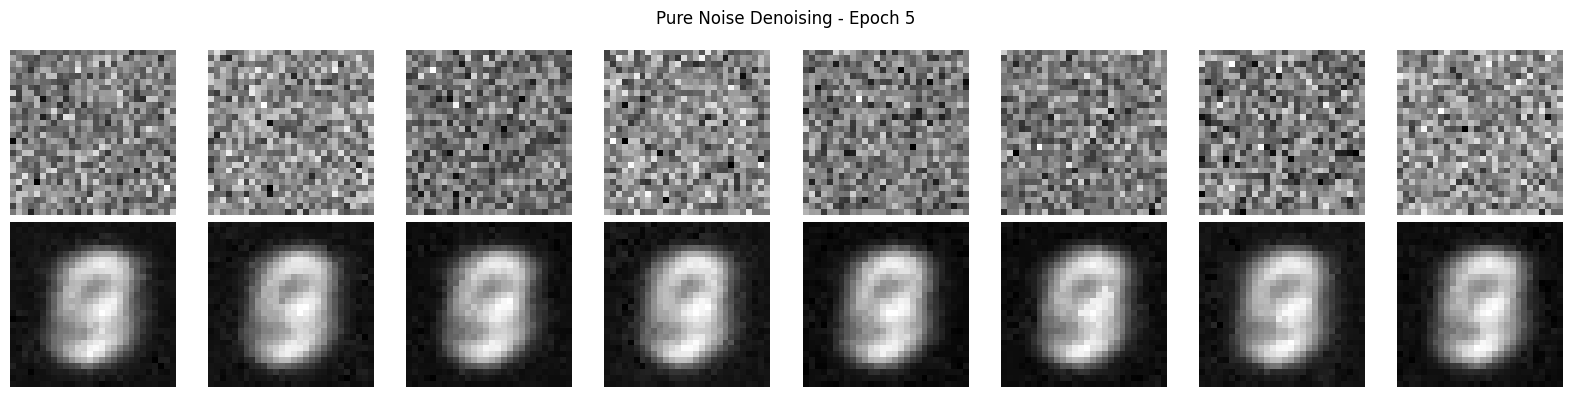

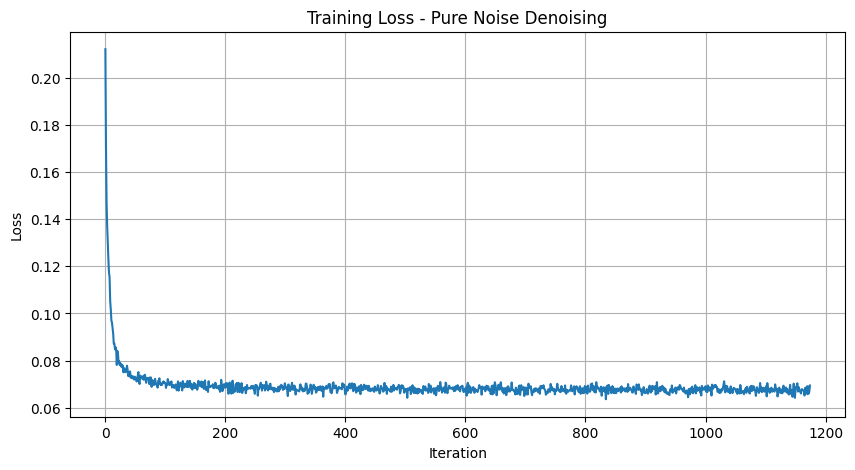

In [17]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
model_pure = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer_pure = torch.optim.Adam(model_pure.parameters(), lr=learning_rate)
criterion_pure = nn.MSELoss()

# Training loop for pure noise denoising
train_losses_pure = []
for epoch in range(num_epochs):
    model_pure.train()
    for i, (images, _) in enumerate(tqdm(train_loader)):
        images = images.to(device)

        # Generate PURE NOISE (not noisy image - just random noise!)
        pure_noise = torch.randn_like(images)

        # Train model to predict clean image FROM pure noise
        outputs = model_pure(pure_noise)

        # Loss: how close is prediction to the actual clean image?
        loss = criterion_pure(outputs, images)
        optimizer_pure.zero_grad()
        loss.backward()
        optimizer_pure.step()

        train_losses_pure.append(loss.item())

    print(f'Epoch {epoch+1}/{num_epochs}, Avg Loss: {sum(train_losses_pure[-len(train_loader):])/len(train_loader):.4f}')

    # Visualize results after epoch 1 and 5
    if epoch == 0 or epoch == num_epochs - 1:
        model_pure.eval()
        with torch.no_grad():
            # Generate from pure noise
            test_noise = torch.randn(8, 1, 28, 28).to(device)
            generated = model_pure(test_noise)

            # Plot
            fig, axes = plt.subplots(2, 8, figsize=(16, 4))
            for j in range(8):
                axes[0, j].imshow(test_noise[j].cpu().squeeze(), cmap='gray')
                axes[0, j].axis('off')
                axes[1, j].imshow(generated[j].cpu().squeeze(), cmap='gray')
                axes[1, j].axis('off')
            axes[0, 0].set_ylabel('Input\n(Pure Noise)', rotation=0, size='large', labelpad=50)
            axes[1, 0].set_ylabel('Output\n(Generated)', rotation=0, size='large', labelpad=50)
            plt.suptitle(f'Pure Noise Denoising - Epoch {epoch+1}')
            plt.tight_layout()
            plt.show()

# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses_pure)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss - Pure Noise Denoising')
plt.grid(True)
plt.show()
# ===== end of code ====

# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [28]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.fc = nn.Linear(in_channels, out_channels)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.fc(x)
        x = self.gelu(x)
        return x
        # ===== end of code ====
        #raise NotImplementedError()


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens
        self.num_hiddens = D
        # Time embedding MLPs
        self.fc1_t = FCBlock(1, 2*D)
        self.fc2_t = FCBlock(1, D)

        # Encoder
        self.conv_in = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2*D)

        # Bottleneck
        self.flatten = Flatten()
        self.unflatten = Unflatten(2*D)

        # Decoder
        self.up1 = UpBlock(2*D, D)
        self.up2 = UpBlock(2*D, D)
        self.conv_out = nn.Conv2d(2*D, in_channels, kernel_size=1)
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        t = t.view(-1, 1)  # Shape: (B, 1)
        t1 = self.fc1_t(t)  # Shape: (B, 2D)
        t2 = self.fc2_t(t)  # Shape: (B, D)

        # Reshape for broadcasting: (B, C, 1, 1)
        t1 = t1.view(-1, 2*self.num_hiddens, 1, 1)
        t2 = t2.view(-1, self.num_hiddens, 1, 1)

        # Encoder
        x1 = self.conv_in(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)

        # Bottleneck with time modulation
        x4 = self.flatten(x3)
        x5 = self.unflatten(x4)
        x5 = x5 * t1  # Time modulation

        # Decoder with skip connections and time modulation
        x6 = self.up1(x5)
        x6 = x6 * t2  # Time modulation
        x7 = torch.cat([x6, x2], dim=1)
        x8 = self.up2(x7)
        x9 = torch.cat([x8, x1], dim=1)
        out = self.conv_out(x9)

        return out
        # ===== end of code ====
        #raise NotImplementedError()

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [29]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    x_0 = torch.randn_like(x_1)

    # Sample random timestep t uniformly from [0, 1]
    t = torch.rand(x_1.shape[0], device=x_1.device)

    # Compute x_t: linear interpolation between x_0 and x_1
    # x_t = (1-t)*x_0 + t*x_1
    t_expanded = t.view(-1, 1, 1, 1)  # Shape: (N, 1, 1, 1) for broadcasting
    x_t = (1 - t_expanded) * x_0 + t_expanded * x_1

    # Compute target flow: u(x_t, t) = x_1 - x_0
    flow_target = x_1 - x_0

    # Predict flow using UNet
    flow_pred = unet(x_t, t)

    # Compute MSE loss
    loss = nn.functional.mse_loss(flow_pred, flow_target)

    return loss
    # ===== end of code ====
    #raise NotImplementedError()

In [30]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # ===== your code here! ====
    torch.manual_seed(seed)

    # Get device from model
    device = next(unet.parameters()).device

    # Start with pure noise x_0 ~ N(0, I)
    # Assuming batch size of 1 and 1 channel (grayscale)
    H, W = img_wh
    x_t = torch.randn(1, 1, H, W, device=device)

    # Time step size
    dt = 1.0 / num_ts

    # Euler method: iteratively integrate from t=0 to t=1
    for i in range(num_ts):
        # Current timestep
        t = torch.ones(1, device=device) * (i / num_ts)

        # Predict flow at current x_t and t
        flow = unet(x_t, t)

        # Euler step: x_{t+dt} = x_t + flow * dt
        x_t = x_t + flow * dt

    return x_t
    # ===== end of code ====
    #raise NotImplementedError()

In [31]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Part 2.2: Training the Time-conditioned UNet

100%|██████████| 938/938 [00:31<00:00, 29.58it/s]


Epoch 1/20, Avg Loss: 0.1836, LR: 0.008913


100%|██████████| 938/938 [00:31<00:00, 29.69it/s]


Epoch 2/20, Avg Loss: 0.1194, LR: 0.007943


100%|██████████| 938/938 [00:30<00:00, 30.59it/s]


...

Epoch 18/20, Avg Loss: 0.0906, LR: 0.001259


100%|██████████| 938/938 [00:30<00:00, 30.60it/s]


Epoch 19/20, Avg Loss: 0.0903, LR: 0.001122


100%|██████████| 938/938 [00:30<00:00, 30.89it/s]


Epoch 20/20, Avg Loss: 0.0900, LR: 0.001000


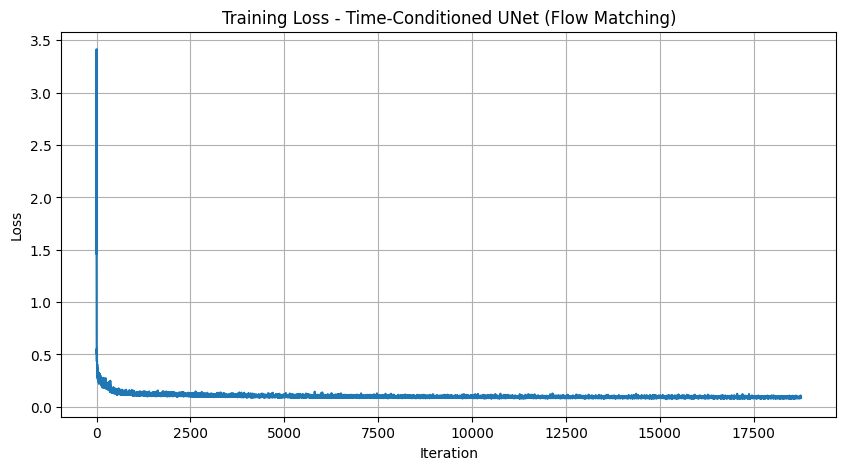

In [32]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
batch_size = 64  # Recommended batch size
num_epochs = 20  # Train for 20 epochs
initial_lr = 1e-2  # Initial learning rate
D = 64  # Hidden dimension

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataset and dataloader
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Create time-conditioned UNet
unet_time = TimeConditionalUNet(in_channels=1, num_hiddens=D).to(device)

# Wrap in TimeConditionalFM
model_fm = TimeConditionalFM(unet=unet_time, num_ts=50, img_hw=(28, 28))

# Optimizer with exponential learning rate decay
optimizer = torch.optim.Adam(model_fm.parameters(), lr=initial_lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1**(1.0/num_epochs))

# Training loop
train_losses_fm = []
for epoch in range(num_epochs):
    model_fm.train()
    epoch_losses = []

    for i, (images, _) in enumerate(tqdm(train_loader)):
        images = images.to(device)  # x_1 (clean images)

        # Forward pass - compute flow matching loss
        loss = model_fm(images)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses_fm.append(loss.item())
        epoch_losses.append(loss.item())

    # Step the learning rate scheduler after each epoch
    scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs}, Avg Loss: {sum(epoch_losses)/len(epoch_losses):.4f}, LR: {scheduler.get_last_lr()[0]:.6f}')

# Plot training loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses_fm)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss - Time-Conditioned UNet (Flow Matching)')
plt.grid(True)
plt.show()

# ===== end of code ====

# Part 2.3: Sampling from the Time-conditioned UNet

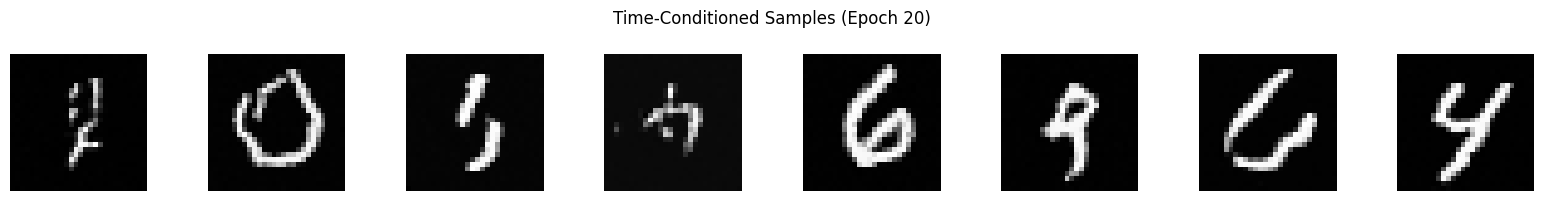

In [33]:
# Sampling from the UNet
# ===== your code here! ====
model_fm.eval()
num_samples = 8
img_hw = (28, 28)

with torch.no_grad():
    samples = model_fm.sample(img_wh=img_hw, seed=42)

    # Reshape to get multiple samples
    # You may want to call sample multiple times for different seeds
    all_samples = []
    for seed in range(num_samples):
        sample = model_fm.sample(img_wh=img_hw, seed=seed)
        all_samples.append(sample)

    all_samples = torch.cat(all_samples, dim=0)  # (num_samples, 1, 28, 28)

    # Visualize
    fig, axes = plt.subplots(1, num_samples, figsize=(16, 2))
    for i in range(num_samples):
        axes[i].imshow(all_samples[i].cpu().squeeze(), cmap='gray')
        axes[i].axis('off')
    plt.suptitle(f'Time-Conditioned Samples (Epoch {epoch+1})')
    plt.tight_layout()
    plt.show()
# ===== end of code ====

# Part 2.4: Implementing a Class-conditioned UNet

In [59]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens
        self.num_hiddens = D
        self.num_classes = num_classes

        # Time embedding MLPs (same as TimeConditionalUNet)
        self.fc1_t = FCBlock(1, 2*D)
        self.fc2_t = FCBlock(1, D)

        # Class embedding MLPs (NEW - for class conditioning)
        # Input is one-hot vector of size num_classes
        self.fc1_c = FCBlock(num_classes, 2*D)
        self.fc2_c = FCBlock(num_classes, D)

        # Encoder (same as before)
        self.conv_in = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2*D)

        # Bottleneck
        self.flatten = Flatten()
        self.unflatten = Unflatten(2*D)

        # Decoder
        self.up1 = UpBlock(2*D, D)
        self.up2 = UpBlock(2*D, D)
        self.conv_out = nn.Conv2d(2*D, in_channels, kernel_size=1)
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        c_one_hot = torch.nn.functional.one_hot(c, num_classes=self.num_classes).float()  # (B, num_classes)

        # Apply mask for classifier-free guidance (set to 0 when mask == 0)
        if mask is not None:
            c_one_hot = c_one_hot * mask.view(-1, 1)

        # Process time conditioning
        t = t.view(-1, 1)  # (B, 1)
        t1 = self.fc1_t(t)  # (B, 2D)
        t2 = self.fc2_t(t)  # (B, D)

        # Process class conditioning
        c1 = self.fc1_c(c_one_hot)  # (B, 2D)
        c2 = self.fc2_c(c_one_hot)  # (B, D)

        # Reshape for broadcasting
        t1 = t1.view(-1, 2*self.num_hiddens, 1, 1)
        t2 = t2.view(-1, self.num_hiddens, 1, 1)
        c1 = c1.view(-1, 2*self.num_hiddens, 1, 1)
        c2 = c2.view(-1, self.num_hiddens, 1, 1)

        # Encoder
        x1 = self.conv_in(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)

        # Bottleneck with combined conditioning: c * feature + t
        x4 = self.flatten(x3)
        x5 = self.unflatten(x4)
        x5 = c1 * x5 + t1  # Class-time modulation

        # Decoder with skip connections and combined conditioning
        x6 = self.up1(x5)
        x6 = c2 * x6 + t2  # Class-time modulation
        x7 = torch.cat([x6, x2], dim=1)
        x8 = self.up2(x7)
        x9 = torch.cat([x8, x1], dim=1)
        out = self.conv_out(x9)

        return out
        # ===== end of code ====
        #raise NotImplementedError()

In [60]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    x_0 = torch.randn_like(x_1)

    # Sample random timestep t uniformly from [0, 1]
    t = torch.rand(x_1.shape[0], device=x_1.device)

    # Compute x_t: linear interpolation between x_0 and x_1
    t_expanded = t.view(-1, 1, 1, 1)
    x_t = (1 - t_expanded) * x_0 + t_expanded * x_1

    # Create mask for classifier-free guidance
    # With probability p_uncond, set mask to 0 (drop conditioning)
    mask = (torch.rand(x_1.shape[0], device=x_1.device) > p_uncond).float()

    # Compute target flow: u(x_t, t) = x_1 - x_0
    flow_target = x_1 - x_0

    # Predict flow using UNet with class conditioning and mask
    flow_pred = unet(x_t, c, t, mask=mask)

    # Compute MSE loss
    loss = nn.functional.mse_loss(flow_pred, flow_target)

    return loss
    # ===== end of code ====
    #raise NotImplementedError()

In [64]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # ===== your code here! ====
    torch.manual_seed(seed)
    device = next(unet.parameters()).device

    # Start with pure noise x_0 ~ N(0, I)
    H, W = img_wh
    N = c.shape[0]  # Batch size from condition tensor
    x_t = torch.randn(N, 1, H, W, device=device)

    # Time step size
    dt = 1.0 / num_ts

    # Create mask tensors for conditional and unconditional predictions
    mask_cond = torch.ones(N, device=device)  # All 1s for conditional
    mask_uncond = torch.zeros(N, device=device)  # All 0s for unconditional

    # Store intermediate results for animation (optional)
    caches = []

    # Euler method with classifier-free guidance
    for i in range(num_ts):
        # Current timestep
        t = torch.ones(N, device=device) * (i / num_ts)

        # Predict flow with conditioning
        flow_cond = unet(x_t, c, t, mask=mask_cond)

        # Predict flow without conditioning (unconditional)
        flow_uncond = unet(x_t, c, t, mask=mask_uncond)

        # Apply classifier-free guidance
        # flow = flow_uncond + gamma * (flow_cond - flow_uncond)
        flow = flow_uncond + guidance_scale * (flow_cond - flow_uncond)

        # Euler step: x_{t+dt} = x_t + flow * dt
        x_t = x_t + flow * dt

        # Store intermediate result (every few steps to save memory)
        if i % (num_ts // 10) == 0 or i == num_ts - 1:
            caches.append(x_t.clone())

    # Stack caches: (N, T_animation, C, H, W)
    caches = torch.stack(caches, dim=1)

    return x_t, caches
    # ===== end of code ====
    #raise NotImplementedError()

In [65]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

100%|██████████| 938/938 [00:31<00:00, 29.40it/s]


Epoch 1/10, Avg Loss: 0.1830, LR: 0.007943
Saved checkpoint: class_fm_epoch_1.pth


100%|██████████| 938/938 [00:31<00:00, 29.86it/s]


Epoch 2/10, Avg Loss: 0.1108, LR: 0.006310


100%|██████████| 938/938 [00:31<00:00, 30.03it/s]


...

Epoch 8/10, Avg Loss: 0.0880, LR: 0.001585


100%|██████████| 938/938 [00:31<00:00, 30.10it/s]


Epoch 9/10, Avg Loss: 0.0871, LR: 0.001259


100%|██████████| 938/938 [00:31<00:00, 30.25it/s]


Epoch 10/10, Avg Loss: 0.0862, LR: 0.001000
Saved checkpoint: class_fm_epoch_10.pth


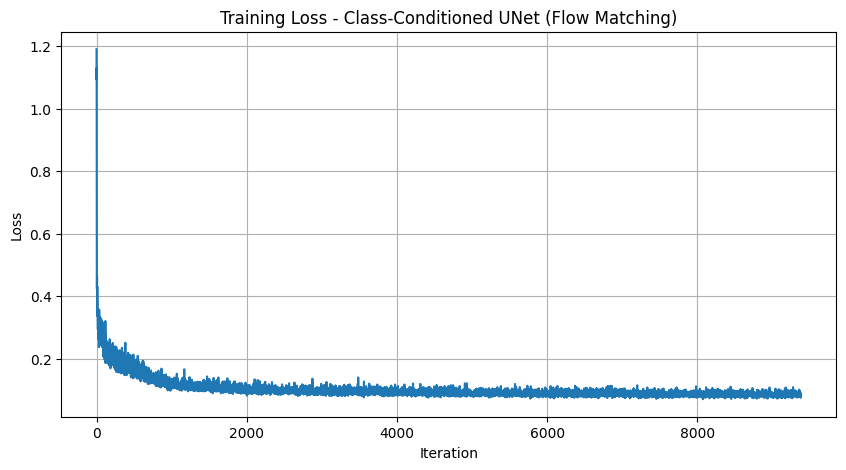

In [71]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====

batch_size = 64  # Recommended batch size
num_epochs = 10  # Train for 10 epochs (class conditioning converges faster)
initial_lr = 1e-2  # Initial learning rate
D = 64  # Hidden dimension
p_uncond = 0.1  # 10% unconditional probability

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataset and dataloader
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Create class-conditional UNet
unet_class = ClassConditionalUNet(in_channels=1, num_classes=10, num_hiddens=D).to(device)

# Wrap in ClassConditionalFM
model_class_fm = ClassConditionalFM(unet=unet_class, num_ts=50, p_uncond=p_uncond)

# Optimizer with exponential learning rate decay
optimizer = torch.optim.Adam(model_class_fm.parameters(), lr=initial_lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1**(1.0/num_epochs))

# Training loop
train_losses_class = []
epochs_to_save = [1, 5, 10]  # Save checkpoints at these epochs

for epoch in range(num_epochs):
    model_class_fm.train()
    epoch_losses = []

    for i, (images, labels) in enumerate(tqdm(train_loader)):
        images = images.to(device)  # x_1 (clean images)
        labels = labels.to(device)  # c (class labels)

        # Forward pass - compute flow matching loss with class conditioning
        loss = model_class_fm(images, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses_class.append(loss.item())
        epoch_losses.append(loss.item())

    # Step the learning rate scheduler after each epoch
    scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs}, Avg Loss: {sum(epoch_losses)/len(epoch_losses):.4f}, LR: {scheduler.get_last_lr()[0]:.6f}')

    # Save checkpoint at specific epochs
    if (epoch + 1) in epochs_to_save:
        checkpoint_path = f'class_fm_epoch_{epoch+1}.pth'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model_class_fm.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': sum(epoch_losses)/len(epoch_losses),
        }, checkpoint_path)
        print(f'Saved checkpoint: {checkpoint_path}')

# Plot training loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses_class)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss - Class-Conditioned UNet (Flow Matching)')
plt.grid(True)
plt.show()

# ===== end of code ====

# Part 2.6: Sampling from the Class-conditioned UNet

Loaded checkpoint from Epoch 1
Training loss at that epoch: 0.1830


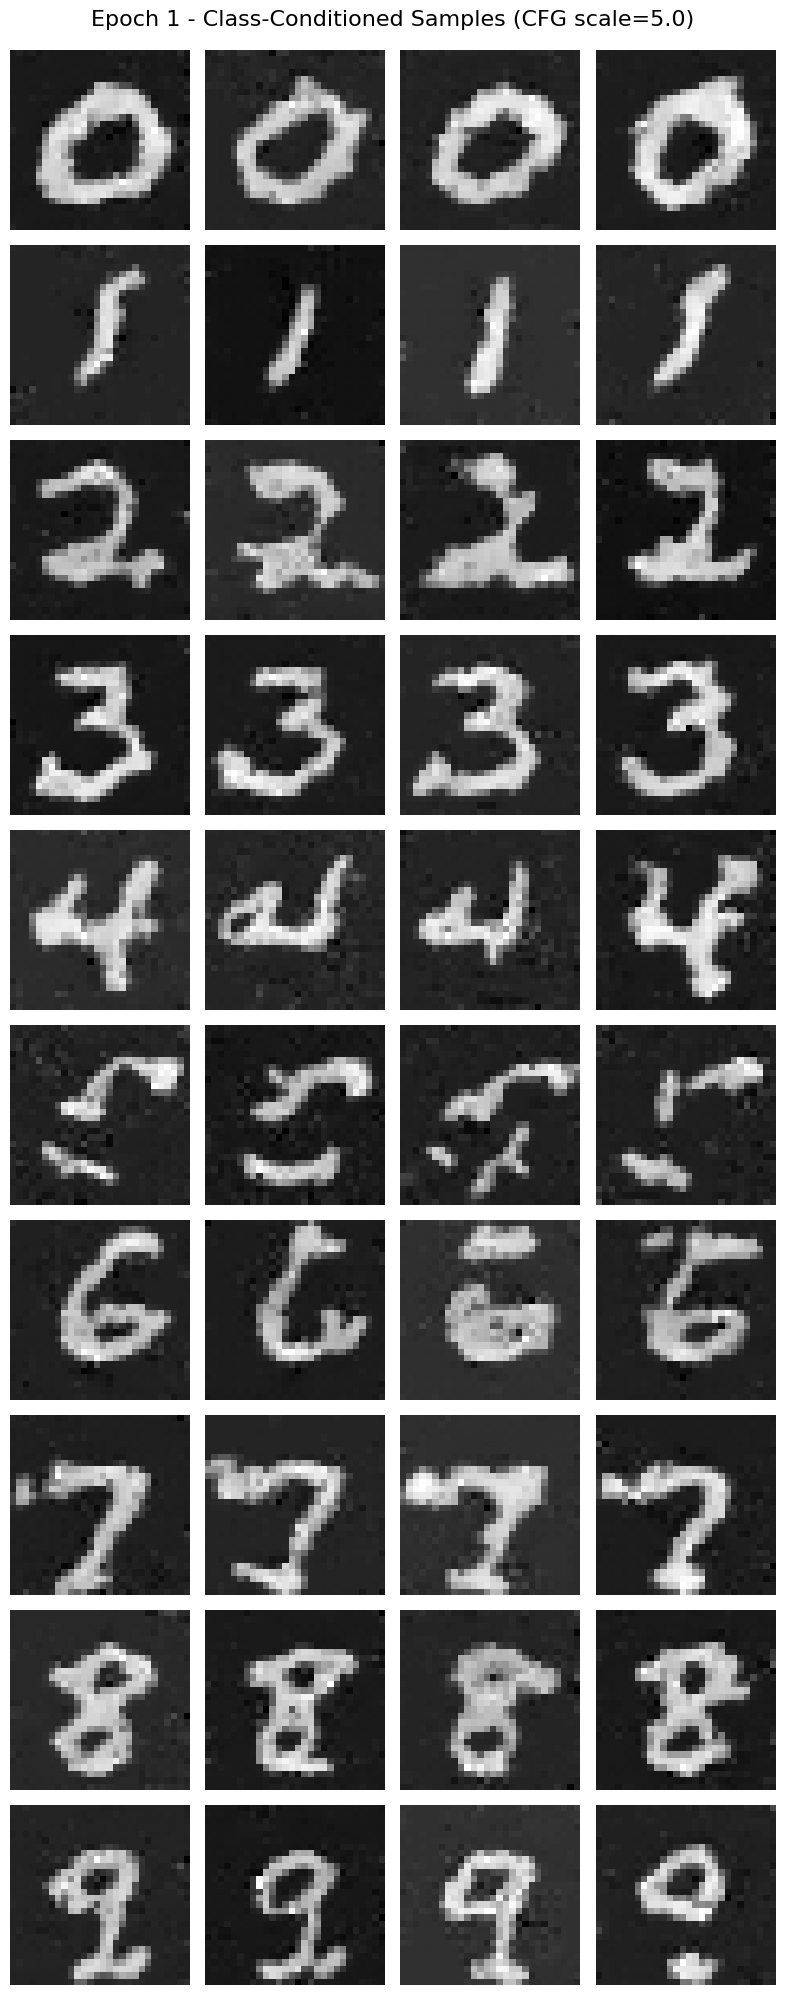

Loaded checkpoint from Epoch 5
Training loss at that epoch: 0.0926


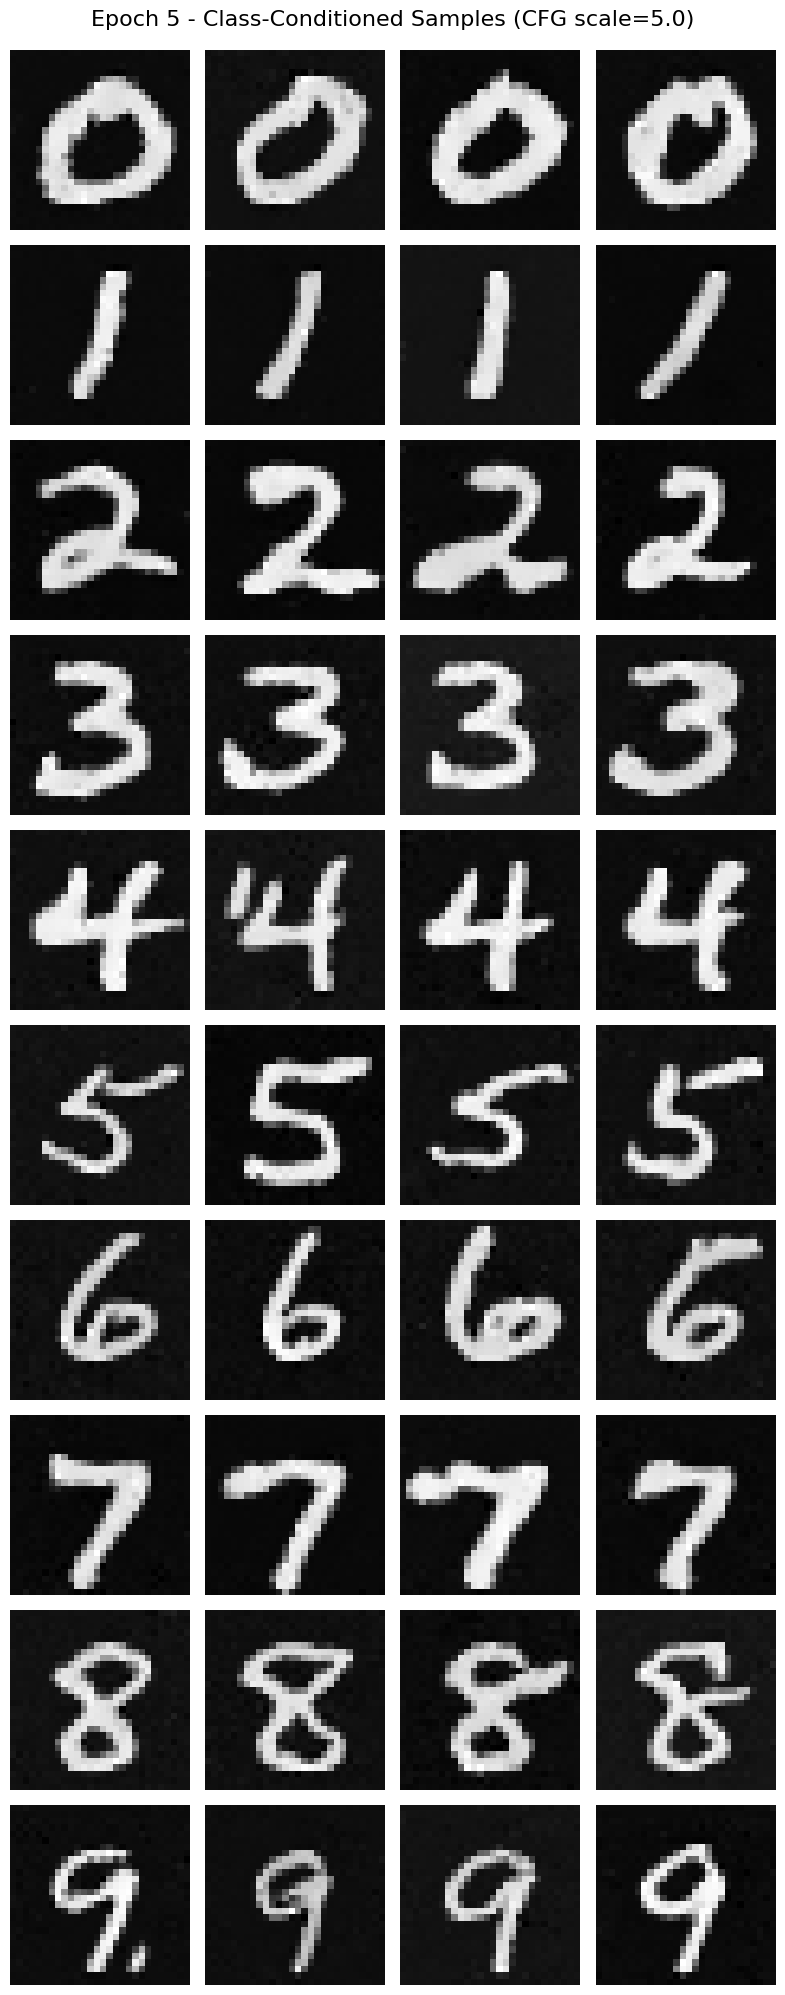

Loaded checkpoint from Epoch 10
Training loss at that epoch: 0.0862


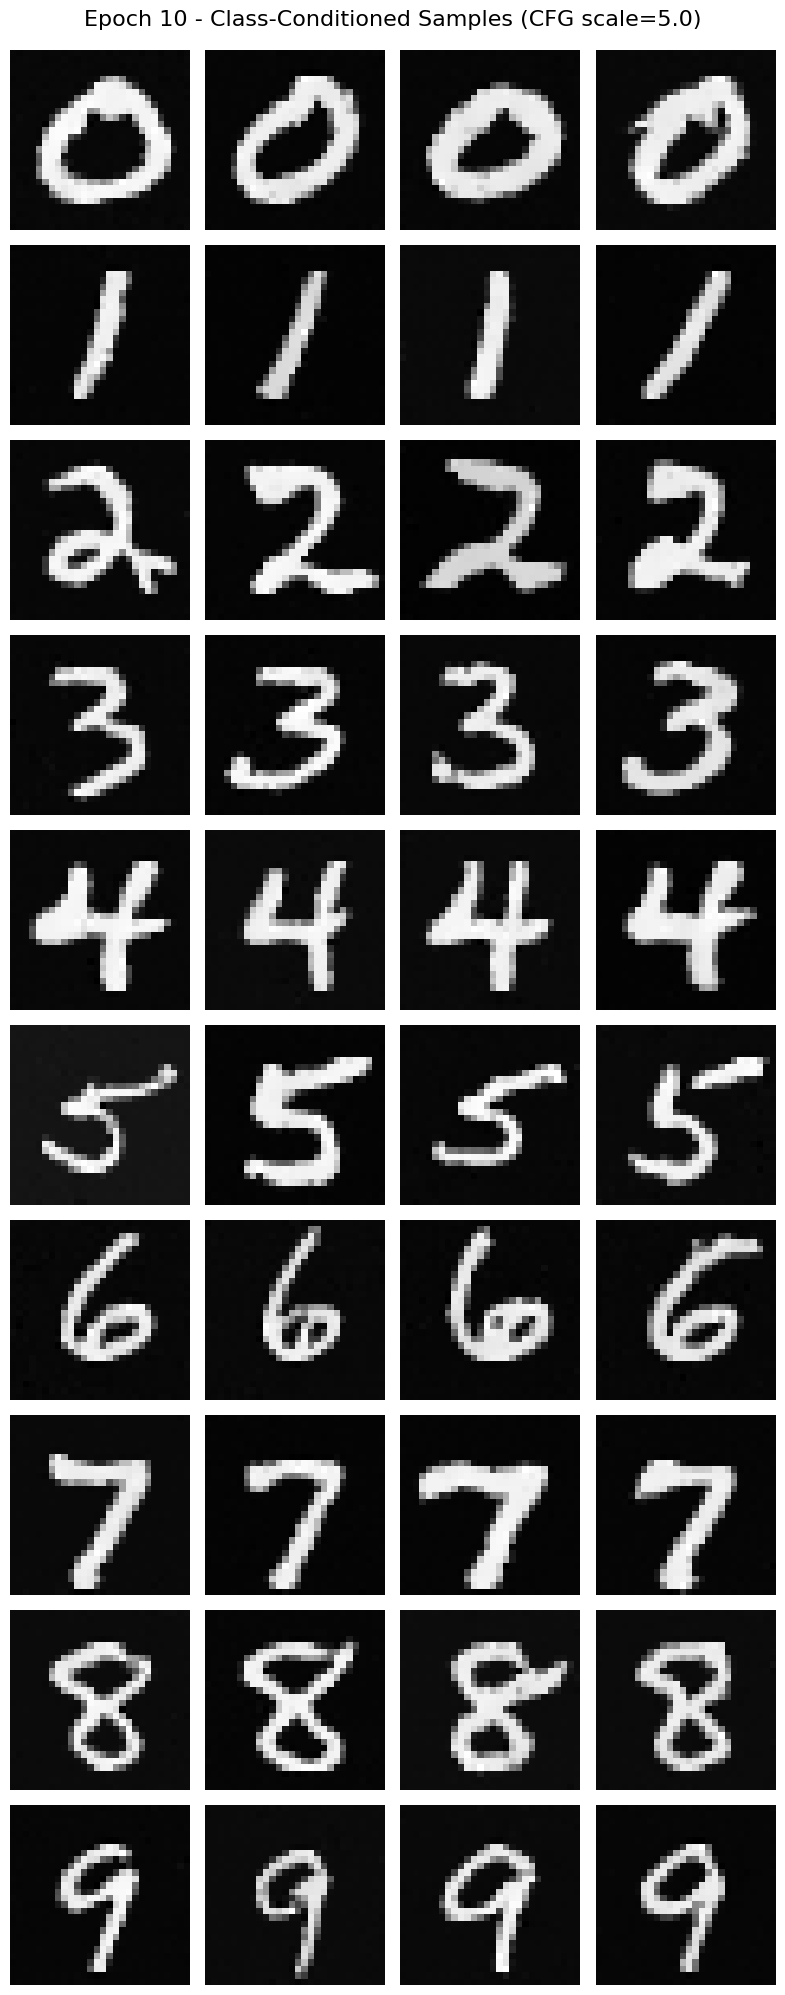

In [72]:
# Sampling from the UNet
# ===== your code here! ====

# Define all parameters
num_samples_per_class = 4  # 4 instances of each digit
num_classes = 10  # Digits 0-9
img_hw = (28, 28)
guidance_scale = 5.0
D = 64  # Must match training

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Recreate the model architecture (must match training)
unet_class = ClassConditionalUNet(in_channels=1, num_classes=10, num_hiddens=D).to(device)
model_class_fm = ClassConditionalFM(unet=unet_class, num_ts=50, p_uncond=0.1)

# Sample from checkpoints at epochs 1, 5, and 10
epochs_to_load = [1, 5, 10]

for epoch_num in epochs_to_load:
    # Load checkpoint
    checkpoint_path = f'class_fm_epoch_{epoch_num}.pth'
    checkpoint = torch.load(checkpoint_path)
    model_class_fm.load_state_dict(checkpoint['model_state_dict'])

    print(f"Loaded checkpoint from Epoch {epoch_num}")
    print(f"Training loss at that epoch: {checkpoint['loss']:.4f}")

    # Generate samples
    with torch.no_grad():
        # Create a batch with all class labels: [0,0,0,0, 1,1,1,1, ..., 9,9,9,9]
        all_classes = torch.arange(num_classes, device=device).repeat_interleave(num_samples_per_class)

        # Sample all at once
        samples, caches = model_class_fm.sample(
            c=all_classes,
            img_wh=img_hw,
            guidance_scale=guidance_scale,
            seed=42
        )

    # Visualize results in a 10x4 grid
    fig, axes = plt.subplots(num_classes, num_samples_per_class, figsize=(8, 20))

    for i in range(num_classes):
        for j in range(num_samples_per_class):
            idx = i * num_samples_per_class + j
            axes[i, j].imshow(samples[idx].cpu().squeeze(), cmap='gray')
            axes[i, j].axis('off')

            # Add digit label on the left
            if j == 0:
                axes[i, j].set_ylabel(f'{i}', fontsize=14, rotation=0, labelpad=20, va='center')

    plt.suptitle(f'Epoch {epoch_num} - Class-Conditioned Samples (CFG scale={guidance_scale})', fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()

# ===== end of code ====

In [70]:
# Clear GPU cache and reset model (run this before retraining)
import gc

# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Clear Python garbage
gc.collect()

# If you have old model variables, delete them
try:
    del model_class_fm
    del unet_class
    del optimizer
    del scheduler
except:
    pass

print("Cache cleared! Ready to retrain.")

Cache cleared! Ready to retrain.
